In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Define paths
normal_path = '/content/drive/MyDrive/AI Project dataset/train  normal'
pneumonia_path = '/content/drive/MyDrive/AI Project dataset/train pneumonia'

In [ ]:
import os



num_normal_images = len(os.listdir(normal_path))
num_pneumonia_images = len(os.listdir(pneumonia_path))

print(f'Number of normal images: {num_normal_images}')
print(f'Number of pneumonia images: {num_pneumonia_images}')


Number of normal images: 2690
Number of pneumonia images: 7758


<ipython-input-11-1b2cbfed176b>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=counts, palette=['lightblue', 'salmon'])


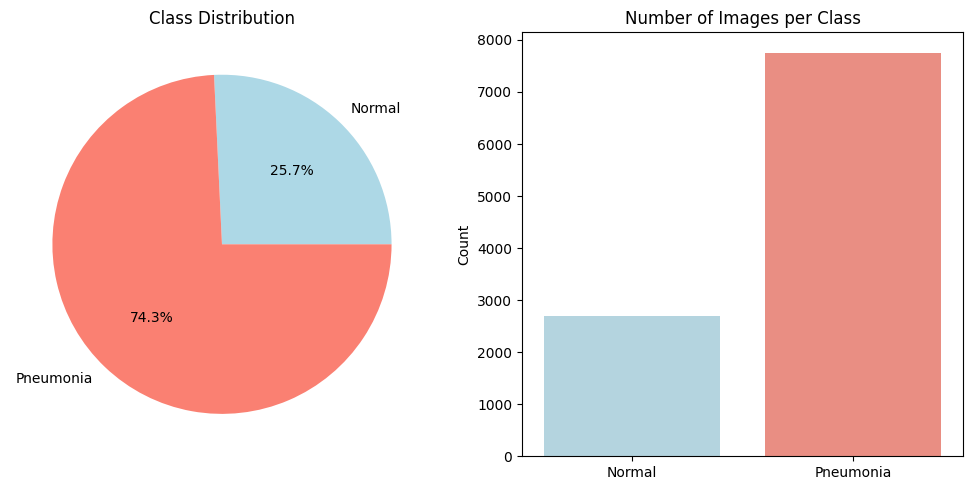

In [ ]:
# Dataset statistics
categories = ['Normal', 'Pneumonia']
counts = [2690, 7758]

# Pie chart
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(counts, labels=categories, autopct='%1.1f%%', colors=['lightblue', 'salmon'])
plt.title('Class Distribution')

# Bar plot
plt.subplot(1, 2, 2)
sns.barplot(x=categories, y=counts, palette=['lightblue', 'salmon'])
plt.title('Number of Images per Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:


import os

print(os.listdir(normal_path))
print(os.listdir(pneumonia_path))


['NORMAL-338872-0001.jpeg', 'NORMAL-3387483-0002.jpeg', 'NORMAL-3476904-0001.jpeg', 'NORMAL-3400382-0002.jpeg', 'NORMAL-3399582-0002.jpeg', 'NORMAL-332359-0001.jpeg', 'NORMAL-3411116-0002.jpeg', 'NORMAL-3260755-0001.jpeg', 'NORMAL-3482198-0004.jpeg', 'NORMAL-3371493-0001.jpeg', 'NORMAL-3411116-0003.jpeg', 'NORMAL-3271929-0001.jpeg', 'NORMAL-3482198-0003.jpeg', 'NORMAL-3744578-0001.jpeg', 'NORMAL-3665449-0001.jpeg', 'NORMAL-3684474-0001.jpeg', 'NORMAL-3502771-0002.jpeg', 'NORMAL-3514363-0001.jpeg', 'NORMAL-3747940-0001.jpeg', 'NORMAL-3573766-0001.jpeg', 'NORMAL-3624836-0001.jpeg', 'NORMAL-3518986-0001.jpeg', 'NORMAL-3706164-0001.jpeg', 'NORMAL-3688916-0002.jpeg', 'NORMAL-3493370-0001.jpeg', 'NORMAL-3751100-0001.jpeg', 'NORMAL-3678361-0001.jpeg', 'NORMAL-3570271-0001.jpeg', 'NORMAL-3644944-0001.jpeg', 'NORMAL-3573766-0004.jpeg', 'NORMAL-3744309-0001.jpeg', 'NORMAL-3573766-0002.jpeg', 'NORMAL-3518933-0002.jpeg', 'NORMAL-3573766-0003.jpeg', 'NORMAL-3518933-0001.jpeg', 'NORMAL-3685250-0001.

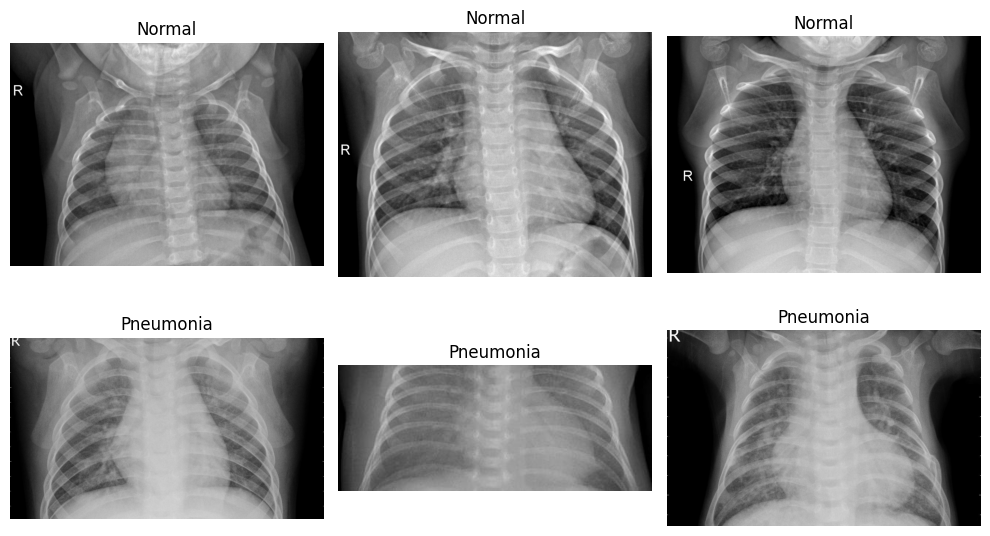

In [ ]:
# Display sample images
def plot_sample_images():
    normal_images = [os.path.join(normal_path, f) for f in os.listdir(normal_path)[:3]]
    pneumonia_images = [os.path.join(pneumonia_path, f) for f in os.listdir(pneumonia_path)[:3]]

    plt.figure(figsize=(10, 6))
    for i, img_path in enumerate(normal_images + pneumonia_images):
        plt.subplot(2, 3, i+1)
        img = plt.imread(img_path)
        plt.imshow(img, cmap='gray')
        plt.title('Normal' if i < 3 else 'Pneumonia')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images()

In [ ]:
# Image dimensions
img_width, img_height = 150, 150
batch_size = 32

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Using 20% for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/AI Project dataset',  # Parent directory containing both classes
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['test normal', 'test pneumonia']  # Subfolder names
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/AI Project dataset',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['test normal', 'test pneumonia']
)

Found 999 images belonging to 2 classes.
Found 249 images belonging to 2 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),

    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,811,969 (25.99 MB)

 Trainable params: 6,811,969 (25.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Training
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[checkpoint, early_stopping]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5347 - loss: 0.7190 - precision: 0.5868 - recall: 0.6799

31/31 ━━━━━━━━━━━━━━━━━━━━ 167s 5s/step - accuracy: 0.5365 - loss: 0.7183 - precision: 0.5879 - recall: 0.6862 - val_accuracy: 0.6339 - val_loss: 0.6695 - val_precision: 0.6339 - val_recall: 1.0000
Epoch 2/30
 1/31 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6562 - loss: 0.6405 - precision: 0.6562 - recall: 1.0000

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 838ms/step - accuracy: 0.6562 - loss: 0.6405 - precision: 0.6562 - recall: 1.0000 - val_accuracy: 0.6339 - val_loss: 0.6640 - val_precision: 0.6339 - val_recall: 1.0000
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.6039 - loss: 0.6782 - precision: 0.6039 - recall: 1.0000 - val_accuracy: 0.6250 - val_loss: 0.6579 - val_precision: 0.6250 - val_recall: 1.0000
Epoch 4/30
 1/31 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5625 - loss: 0.6818 - precision: 0.5625 - recall: 1.0000

...

31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.7188 - loss: 0.5604 - precision: 0.6316 - recall: 0.8571 - val_accuracy: 0.8080 - val_loss: 0.4485 - val_precision: 0.8603 - val_recall: 0.8298
Epoch 9/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7734 - loss: 0.4985 - precision: 0.8141 - recall: 0.8156 - val_accuracy: 0.7143 - val_loss: 0.4950 - val_precision: 0.7216 - val_recall: 0.8944
Epoch 10/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 297ms/step - accuracy: 0.6250 - loss: 0.5895 - precision: 0.6842 - recall: 0.6842 - val_accuracy: 0.7411 - val_loss: 0.4949 - val_precision: 0.7561 - val_recall: 0.8732
Epoch 11/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.7635 - loss: 0.4926 - precision: 0.8029 - recall: 0.8181 - val_accuracy: 0.7768 - val_loss: 0.4230 - val_precision: 0.7692 - val_recall: 0.9220
Epoch 12/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step - accuracy: 0.8438 - loss: 0.4273 - precision: 0.8400 - recall: 0.9545 - val_accuracy: 0.6964 - val_loss: 0.5104 - va

31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - accuracy: 0.7812 - loss: 0.3978 - precision: 0.7391 - recall: 0.9444 - val_accuracy: 0.8482 - val_loss: 0.3636 - val_precision: 0.8841 - val_recall: 0.8714
Epoch 15/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8117 - loss: 0.4041 - precision: 0.8553 - recall: 0.8479 - val_accuracy: 0.8125 - val_loss: 0.3816 - val_precision: 0.8529 - val_recall: 0.8406
Epoch 16/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step - accuracy: 0.8750 - loss: 0.3936 - precision: 0.8750 - recall: 0.8750 - val_accuracy: 0.8259 - val_loss: 0.3867 - val_precision: 0.8898 - val_recall: 0.8188
Epoch 17/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7842 - loss: 0.4560 - precision: 0.8205 - recall: 0.8362

31/31 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7838 - loss: 0.4569 - precision: 0.8199 - recall: 0.8364 - val_accuracy: 0.8571 - val_loss: 0.3673 - val_precision: 0.8905 - val_recall: 0.8777
Epoch 18/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 606ms/step - accuracy: 0.8750 - loss: 0.2751 - precision: 0.8846 - recall: 0.9583 - val_accuracy: 0.8080 - val_loss: 0.3721 - val_precision: 0.8356 - val_recall: 0.8652
Epoch 19/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.8191 - loss: 0.4291 - precision: 0.8394 - recall: 0.8724 - val_accuracy: 0.8482 - val_loss: 0.3581 - val_precision: 0.8872 - val_recall: 0.8613
Epoch 20/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.8750 - loss: 0.2742 - precision: 0.9412 - recall: 0.8421 - val_accuracy: 0.8438 - val_loss: 0.3311 - val_precision: 0.8662 - val_recall: 0.8849
Epoch 21/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8323 - loss: 0.4113 - precision: 0.8576 - recall: 0.8823

31/31 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.8324 - loss: 0.4109 - precision: 0.8576 - recall: 0.8823 - val_accuracy: 0.8750 - val_loss: 0.3051 - val_precision: 0.9746 - val_recall: 0.8214
Epoch 22/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 229ms/step - accuracy: 0.8125 - loss: 0.4175 - precision: 1.0000 - recall: 0.7000 - val_accuracy: 0.7946 - val_loss: 0.4271 - val_precision: 0.7784 - val_recall: 0.9353
Epoch 23/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.8145 - loss: 0.4224 - precision: 0.8192 - recall: 0.9083 - val_accuracy: 0.8705 - val_loss: 0.3268 - val_precision: 0.9313 - val_recall: 0.8592
Epoch 24/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.8438 - loss: 0.4807 - precision: 0.8333 - recall: 0.8824 - val_accuracy: 0.8571 - val_loss: 0.3574 - val_precision: 0.9573 - val_recall: 0.8058
Epoch 25/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8357 - loss: 0.3729 - precision: 0.8618 - recall: 0.8683

31/31 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.8363 - loss: 0.3721 - precision: 0.8621 - recall: 0.8692 - val_accuracy: 0.9196 - val_loss: 0.2668 - val_precision: 0.9562 - val_recall: 0.9161
Epoch 26/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.8125 - loss: 0.5400 - precision: 0.8261 - recall: 0.9048 - val_accuracy: 0.8750 - val_loss: 0.3047 - val_precision: 0.9750 - val_recall: 0.8239
Epoch 27/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.8190 - loss: 0.3866 - precision: 0.8582 - recall: 0.8563 - val_accuracy: 0.8929 - val_loss: 0.3003 - val_precision: 0.9385 - val_recall: 0.8841
Epoch 28/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 287ms/step - accuracy: 0.8125 - loss: 0.6221 - precision: 0.8235 - recall: 0.8235 - val_accuracy: 0.8973 - val_loss: 0.2556 - val_precision: 0.9270 - val_recall: 0.9071
Epoch 29/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.8502 - loss: 0.3295 - precision: 0.8788 - recall: 0.8777 - val_accuracy: 0.7902 - val_loss: 0.4027 - val_

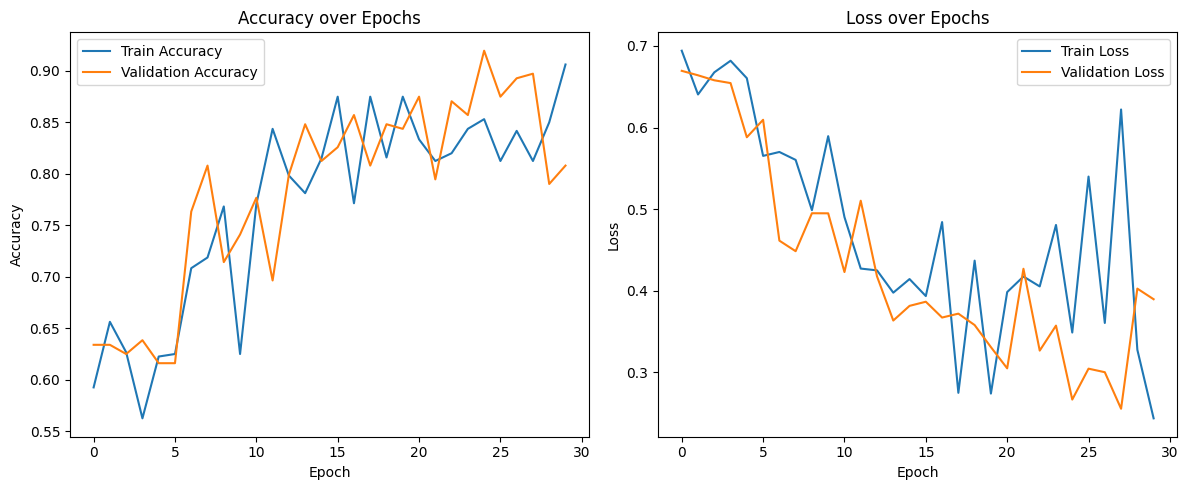

In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Load best model
model = tf.keras.models.load_model('best_model.h5')

# Evaluate on validation set
val_results = model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_results[1]:.4f}")
print(f"Validation Precision: {val_results[2]:.4f}")
print(f"Validation Recall: {val_results[3]:.4f}")

# Predictions
y_true = validation_generator.classes
y_pred_probs = model.predict(validation_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9144 - loss: 0.2401 - precision: 0.9631 - recall: 0.9006
Validation Accuracy: 0.8835
Validation Precision: 0.9379
Validation Recall: 0.8718
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


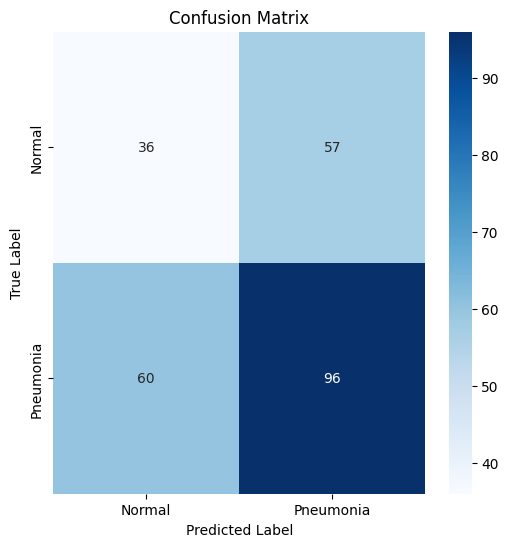


Classification Report:
              precision    recall  f1-score   support

      Normal       0.38      0.39      0.38        93
   Pneumonia       0.63      0.62      0.62       156

    accuracy                           0.53       249
   macro avg       0.50      0.50      0.50       249
weighted avg       0.53      0.53      0.53       249



<ipython-input-19-70a16cfda6d7>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')


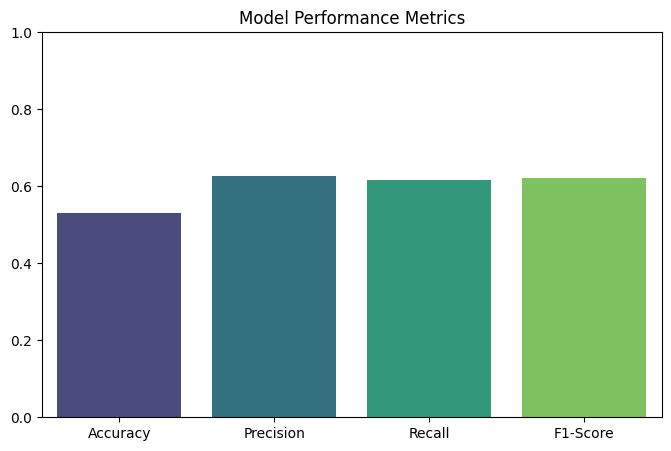

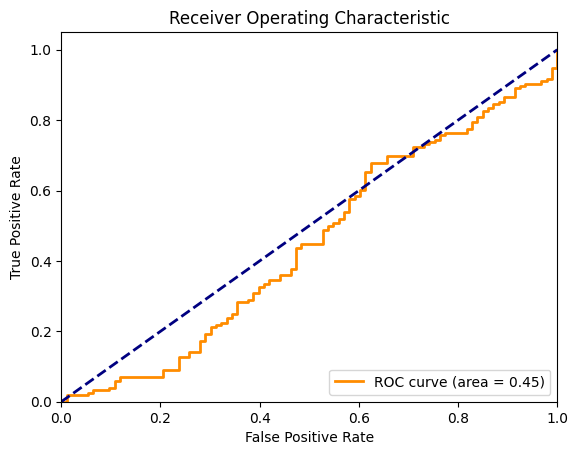

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=categories))

# Metrics Bar Plot
metrics = {
    'Accuracy': accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred),
    'Recall': recall_score(y_true, y_pred),
    'F1-Score': f1_score(y_true, y_pred)
}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
plt.title('Model Performance Metrics')
plt.ylim(0, 1)
plt.show()

# ROC Curve (if you want to add)
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()